# Principal Component Analysis on the Breast Cancer Dataset

This notebook demonstrates the `PCA` algorithm implemented in the `jiayi_ml` package.

The goal is to reduce a high-dimensional dataset to a lower-dimensional representation while preserving as much variance as possible.

This example emphasizes:

1. Unsupervised dimensionality reduction.
2. Standardization before PCA.
3. Explained variance and explained variance ratio.
4. Two-dimensional visualization.
5. Reconstruction error.
6. Interpretation of PCA projections.
7. Limitations of unsupervised projections in biomedical-style data.


## 1. Problem Statement

Principal Component Analysis, or PCA, is an unsupervised dimensionality reduction method.

The Breast Cancer dataset contains 30 numeric features. PCA creates new variables called principal components, which are linear combinations of the original features.

The first principal component captures the largest possible variance in the data. The second captures the largest remaining variance subject to being orthogonal to the first, and so on.

The main questions in this notebook are:

> How much of the original feature variation can be summarized by a small number of principal components?

> Does a two-dimensional PCA projection reveal structure related to malignant and benign samples?

The diagnosis labels are used only for visualization and interpretation. They are not used when fitting PCA.


## Modeling Hypothesis

Because the Breast Cancer dataset contains many correlated numeric measurements, PCA should be able to summarize much of the feature variation using fewer components.

The main hypothesis is:

> The first few principal components will capture a substantial portion of total variance, and a two-dimensional PCA projection may reveal structure related to malignant and benign samples.

However, PCA is unsupervised and does not use diagnosis labels when fitting. Therefore, visible class separation in a PCA plot should be interpreted as exploratory structure rather than supervised classification performance.


In [1]:
from pathlib import Path
import sys

# Make the local package importable whether the notebook is run from the
# project root or from inside the examples directory.
current_path = Path.cwd().resolve()
for candidate in [current_path, *current_path.parents]:
    if (candidate / "src" / "jiayi_ml").exists():
        sys.path.insert(0, str(candidate / "src"))
        PROJECT_ROOT = candidate
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from jiayi_ml.preprocessing import StandardScaler
from jiayi_ml.unsupervised import PCA
from jiayi_ml.metrics import mean_squared_error, root_mean_squared_error

np.random.seed(438)
pd.set_option("display.precision", 4)


## 2. Load the Dataset

The dataset is loaded from `sklearn.datasets.load_breast_cancer`, so this notebook is reproducible without external downloads.

The dataset contains numeric features computed from digitized images of breast mass cell nuclei.

The original sklearn target encoding is:

- `0` = malignant
- `1` = benign

For this notebook, we recode the labels only for easier interpretation:

- `1` = malignant
- `0` = benign

These labels are not used in PCA fitting.


In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data
y_original = data.target
feature_names = X.columns.tolist()
target_names = data.target_names

# Recode target for interpretation:
# original 0 = malignant, original 1 = benign
# new 1 = malignant, new 0 = benign
y = (y_original == 0).astype(int)

df = X.copy()
df["malignant"] = y

print("Feature matrix shape:", X.shape)
print("Number of features:", len(feature_names))
print("Original target names:", target_names)

df.head()


Feature matrix shape: (569, 30)
Number of features: 30
Original target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,1
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,1
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,1
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,1
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,1


## 3. Exploratory Data Analysis

Before applying PCA, we inspect:

- Missing values
- Feature summary statistics
- Class distribution for later visualization
- Feature scale differences

PCA is sensitive to feature scale because it is based on variance. Features with larger numeric ranges can dominate the principal components if the data is not standardized.


In [3]:
missing_values = df.isna().sum()

print("Total missing values:", int(missing_values.sum()))

summary = X.describe().T
summary.head(12)


Total missing values: 0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100
mean texture,569.0,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800
mean perimeter,569.0,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000
mean area,569.0,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000
mean smoothness,569.0,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634
mean compactness,569.0,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454
mean concavity,569.0,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268
mean concave points,569.0,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012
mean symmetry,569.0,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040
mean fractal dimension,569.0,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974


In [4]:
class_counts = pd.Series(y).value_counts().sort_index()
class_counts.index = ["benign (0)", "malignant (1)"]

class_counts_df = class_counts.to_frame(name="count")
class_counts_df["proportion"] = class_counts_df["count"] / class_counts_df["count"].sum()
class_counts_df


,count,proportion
benign (0),357,0.6274
malignant (1),212,0.3726


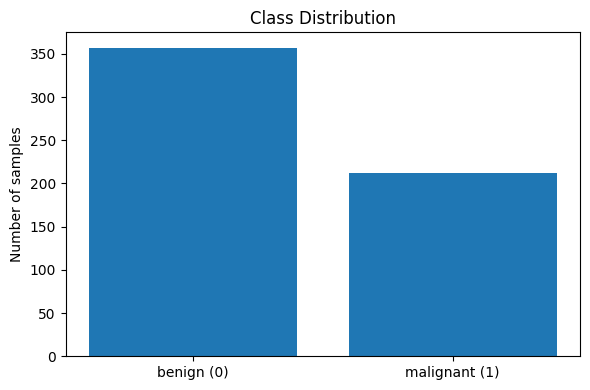

In [5]:
plt.figure(figsize=(6, 4))
plt.bar(class_counts_df.index, class_counts_df["count"])
plt.ylabel("Number of samples")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()


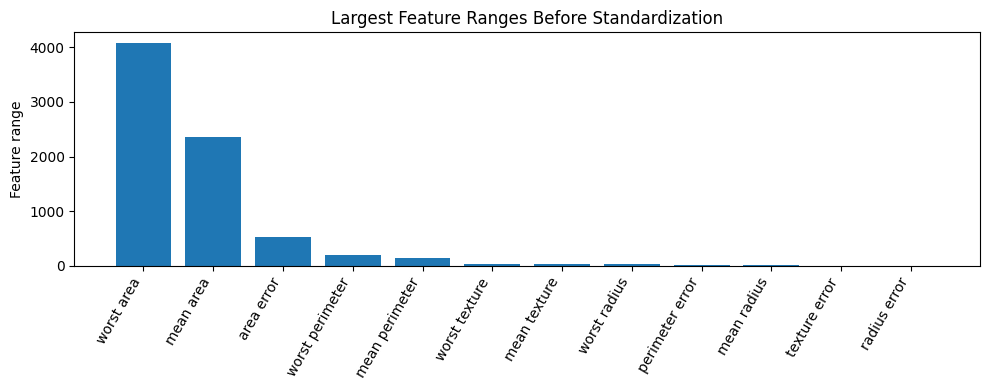

,range
worst area,4068.8000
mean area,2357.5000
area error,535.3980
worst perimeter,200.7900
mean perimeter,144.7100
worst texture,37.5200
mean texture,29.5700
worst radius,28.1100
perimeter error,21.2230
mean radius,21.1290


In [6]:
feature_ranges = (X.max() - X.min()).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(feature_ranges.index[:12], feature_ranges.values[:12])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Feature range")
plt.title("Largest Feature Ranges Before Standardization")
plt.tight_layout()
plt.show()

feature_ranges.head(12).to_frame(name="range")


The feature ranges differ substantially. This confirms that standardization is necessary before PCA. Without standardization, high-range variables could dominate the components even if they are not intrinsically more informative.


## 4. Standardization

PCA is fitted on standardized features.

Each feature is centered and scaled to have mean 0 and standard deviation 1. This makes the PCA directions depend on correlation structure rather than raw feature scale.


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

scaled_summary = pd.DataFrame(X_scaled, columns=feature_names).describe().T
scaled_summary[["mean", "std"]].head(10)


,mean,std
mean radius,-3.1531e-15,1.0009
mean texture,-6.5685e-15,1.0009
mean perimeter,-6.9930e-16,1.0009
mean area,-8.5540e-16,1.0009
mean smoothness,6.0814e-15,1.0009
mean compactness,-1.1364e-15,1.0009
mean concavity,-2.9970e-16,1.0009
mean concave points,1.0240e-15,1.0009
mean symmetry,-1.8606e-15,1.0009
mean fractal dimension,-1.5048e-15,1.0009


The standardized features have approximately mean 0 and standard deviation 1. This makes the features comparable before dimensionality reduction.


## 5. Fit PCA with All Components

We first fit PCA while keeping all possible components. This allows us to inspect the full explained variance pattern.

The labels are not used when fitting PCA.


In [8]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

print("PCA transformed shape:", X_pca_full.shape)
print("Components shape:", pca_full.components_.shape)
print("Explained variance ratio shape:", pca_full.explained_variance_ratio_.shape)
print("Sum of explained variance ratio:", np.sum(pca_full.explained_variance_ratio_))


PCA transformed shape: (569, 30)
Components shape: (30, 30)
Explained variance ratio shape: (30,)
Sum of explained variance ratio: 1.0


## 6. Explained Variance

The explained variance ratio tells us what proportion of total variance is captured by each principal component.

The cumulative explained variance shows how many components are needed to capture a given amount of variation.


In [9]:
explained_df = pd.DataFrame(
    {
        "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
        "explained_variance": pca_full.explained_variance_,
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance_ratio": np.cumsum(pca_full.explained_variance_ratio_),
    }
)

explained_df.head(12)


,component,explained_variance,explained_variance_ratio,cumulative_explained_variance_ratio
0,1,13.3050,0.4427,0.4427
1,2,5.7014,0.1897,0.6324
2,3,2.8229,0.0939,0.7264
3,4,1.9841,0.0660,0.7924
4,5,1.6516,0.0550,0.8473
5,6,1.2095,0.0402,0.8876
6,7,0.6764,0.0225,0.9101
7,8,0.4775,0.0159,0.9260
8,9,0.4176,0.0139,0.9399
9,10,0.3513,0.0117,0.9516


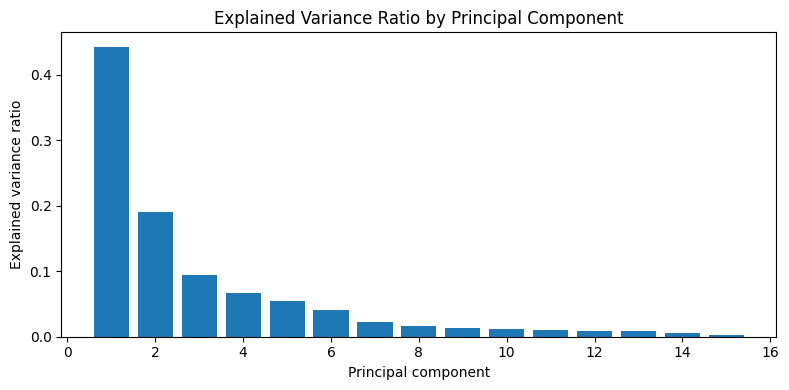

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(
    explained_df["component"][:15],
    explained_df["explained_variance_ratio"][:15],
)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Explained Variance Ratio by Principal Component")
plt.tight_layout()
plt.show()


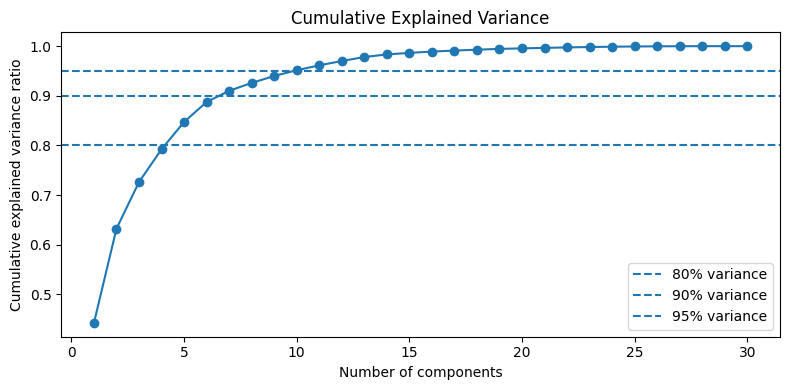

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(
    explained_df["component"],
    explained_df["cumulative_explained_variance_ratio"],
    marker="o",
)
plt.axhline(0.80, linestyle="--", label="80% variance")
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.axhline(0.95, linestyle="--", label="95% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
for threshold in [0.80, 0.90, 0.95]:
    n_needed = int(np.argmax(explained_df["cumulative_explained_variance_ratio"].values >= threshold) + 1)
    print(f"Components needed for {int(threshold * 100)}% variance: {n_needed}")


Components needed for 80% variance: 5
Components needed for 90% variance: 7
Components needed for 95% variance: 10


The explained variance analysis shows how much dimensionality reduction is possible. If a small number of components captures most of the variance, PCA can provide a compact summary of the dataset.

However, variance is not the same as predictive usefulness. A component can explain substantial variance without being the best direction for class separation.


## 7. Two-Dimensional PCA Projection

Next, we fit PCA with two components and visualize the data in two dimensions.

The diagnosis label is used only for coloring the plot after PCA has already been fit. PCA itself does not use the label.


In [13]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_2d_df = pd.DataFrame(
    X_pca_2d,
    columns=["PC1", "PC2"],
)
pca_2d_df["malignant"] = y
pca_2d_df["label"] = pca_2d_df["malignant"].map({0: "benign", 1: "malignant"})

print("2D PCA shape:", X_pca_2d.shape)
print("Explained variance ratio:", pca_2d.explained_variance_ratio_)
print("Total variance explained by first two PCs:", np.sum(pca_2d.explained_variance_ratio_))

pca_2d_df.head()


2D PCA shape: (569, 2)
Explained variance ratio: [0.44272026 0.18971182]
Total variance explained by first two PCs: 0.6324320765155942


,PC1,PC2,malignant,label
0,-9.1928,-1.9486,1,malignant
1,-2.3878,3.7682,1,malignant
2,-5.7339,1.0752,1,malignant
3,-7.1230,-10.2756,1,malignant
4,-3.9353,1.9481,1,malignant


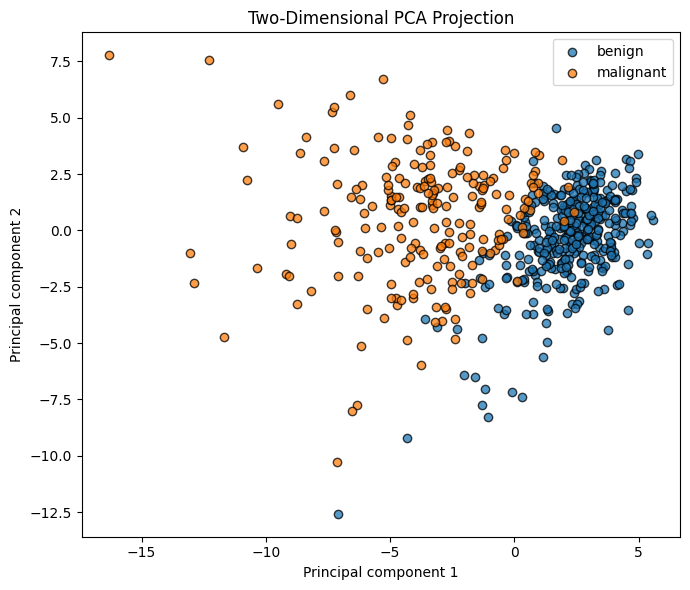

In [14]:
plt.figure(figsize=(7, 6))

for label_value, label_name in [(0, "benign"), (1, "malignant")]:
    mask = pca_2d_df["malignant"] == label_value
    plt.scatter(
        pca_2d_df.loc[mask, "PC1"],
        pca_2d_df.loc[mask, "PC2"],
        alpha=0.75,
        edgecolors="k",
        label=label_name,
    )

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("Two-Dimensional PCA Projection")
plt.legend()
plt.tight_layout()
plt.show()


The two-dimensional PCA projection can reveal whether high-dimensional feature variation aligns with diagnosis-related structure.

If malignant and benign samples show visible separation, this suggests that the high-dimensional measurements contain structure related to diagnosis. However, PCA is unsupervised, so the components are not optimized for classification.


## 8. Component Loadings

Each principal component is a linear combination of the original standardized features.

The loading values show how strongly each original feature contributes to a component. Large positive or negative loadings indicate features that strongly influence the component direction.


In [15]:
loadings_df = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_names,
    columns=["PC1_loading", "PC2_loading"],
)

loadings_df["abs_PC1_loading"] = loadings_df["PC1_loading"].abs()
loadings_df["abs_PC2_loading"] = loadings_df["PC2_loading"].abs()

loadings_df.sort_values("abs_PC1_loading", ascending=False).head(12)


,PC1_loading,PC2_loading,abs_PC1_loading,abs_PC2_loading
mean concave points,-0.2609,0.0348,0.2609,0.0348
mean concavity,-0.2584,-0.0602,0.2584,0.0602
worst concave points,-0.2509,0.0083,0.2509,0.0083
mean compactness,-0.2393,-0.1519,0.2393,0.1519
worst perimeter,-0.2366,0.1999,0.2366,0.1999
worst concavity,-0.2288,-0.0980,0.2288,0.0980
worst radius,-0.2280,0.2199,0.2280,0.2199
mean perimeter,-0.2275,0.2152,0.2275,0.2152
worst area,-0.2249,0.2194,0.2249,0.2194
mean area,-0.2210,0.2311,0.2210,0.2311


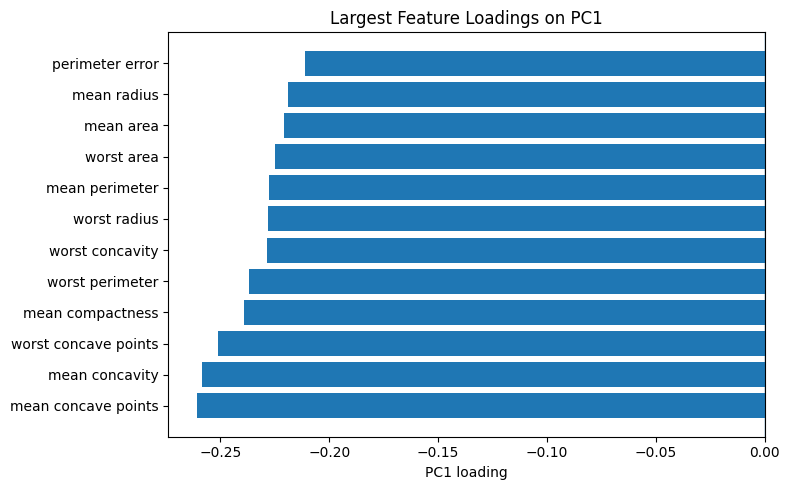

In [16]:
top_pc1 = loadings_df.sort_values("abs_PC1_loading", ascending=False).head(12)
top_pc1_plot = top_pc1.sort_values("PC1_loading")

plt.figure(figsize=(8, 5))
plt.barh(top_pc1_plot.index, top_pc1_plot["PC1_loading"])
plt.axvline(0, linewidth=1)
plt.xlabel("PC1 loading")
plt.title("Largest Feature Loadings on PC1")
plt.tight_layout()
plt.show()


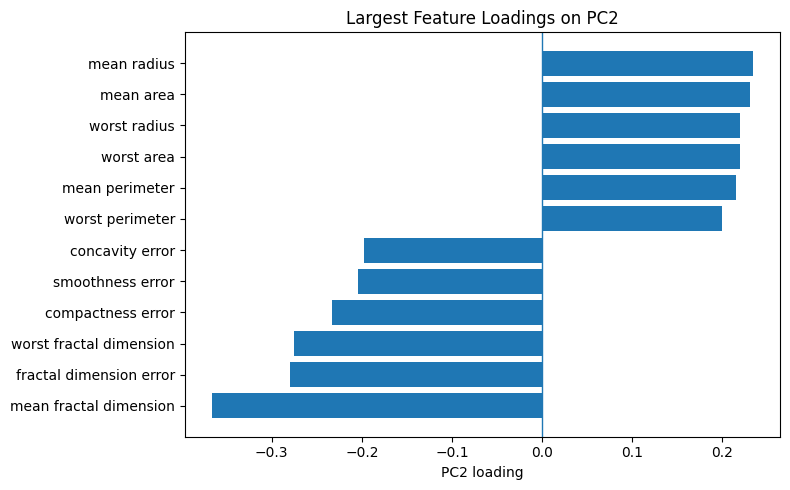

In [17]:
top_pc2 = loadings_df.sort_values("abs_PC2_loading", ascending=False).head(12)
top_pc2_plot = top_pc2.sort_values("PC2_loading")

plt.figure(figsize=(8, 5))
plt.barh(top_pc2_plot.index, top_pc2_plot["PC2_loading"])
plt.axvline(0, linewidth=1)
plt.xlabel("PC2 loading")
plt.title("Largest Feature Loadings on PC2")
plt.tight_layout()
plt.show()


The loading plots help interpret what each component represents. For example, if several size-related features have large loadings on PC1, then PC1 may summarize a general tumor-size pattern.

This interpretation is descriptive. PCA components are mathematical directions of variance, not causal biological factors.


## 9. Reconstruction from Principal Components

PCA can also be viewed as compression. If we keep only a few components, we can reconstruct an approximation of the original standardized data.

The reconstruction error measures how much information is lost when reducing dimensionality.


In [18]:
component_values = [2, 5, 10, 15, 20, 30]
reconstruction_results = []

for n_components in component_values:
    pca = PCA(n_components=n_components)
    X_reduced = pca.fit_transform(X_scaled)
    X_reconstructed = pca.inverse_transform(X_reduced)
    
    reconstruction_results.append(
        {
            "n_components": n_components,
            "cumulative_explained_variance": np.sum(pca.explained_variance_ratio_),
            "MSE": mean_squared_error(X_scaled.ravel(), X_reconstructed.ravel()),
            "RMSE": root_mean_squared_error(X_scaled.ravel(), X_reconstructed.ravel()),
        }
    )

reconstruction_df = pd.DataFrame(reconstruction_results)
reconstruction_df


,n_components,cumulative_explained_variance,MSE,RMSE
0,2,0.6324,3.6757e-01,6.0627e-01
1,5,0.8473,1.5266e-01,3.9071e-01
2,10,0.9516,4.8431e-02,2.2007e-01
3,15,0.9865,1.3512e-02,1.1624e-01
4,20,0.9956,4.4280e-03,6.6543e-02
5,30,1.0000,6.1392e-31,7.8353e-16


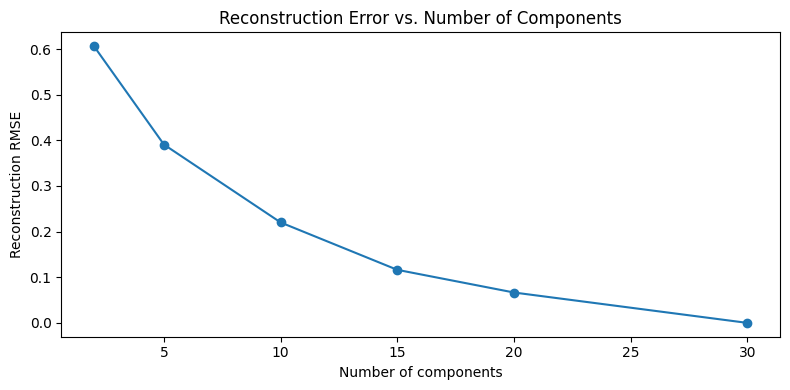

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(
    reconstruction_df["n_components"],
    reconstruction_df["RMSE"],
    marker="o",
)
plt.xlabel("Number of components")
plt.ylabel("Reconstruction RMSE")
plt.title("Reconstruction Error vs. Number of Components")
plt.tight_layout()
plt.show()


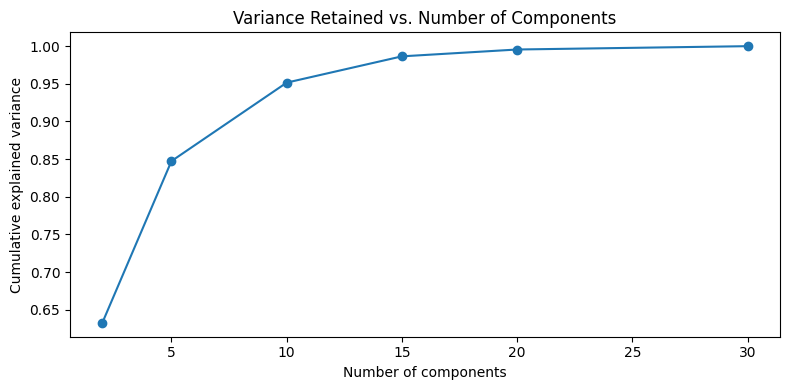

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(
    reconstruction_df["n_components"],
    reconstruction_df["cumulative_explained_variance"],
    marker="o",
)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Variance Retained vs. Number of Components")
plt.tight_layout()
plt.show()


As the number of components increases, reconstruction error decreases and explained variance increases.

This illustrates the trade-off in dimensionality reduction:

- fewer components improve compression and visualization,
- more components preserve more information.


## 10. PCA Is Not Classification

Although the PCA projection is colored by diagnosis labels, PCA itself is not a classifier.

PCA does not use labels. It finds directions that explain variance in the feature matrix, not directions that maximize class separation.

A supervised method such as logistic regression, decision trees, or random forests should be used when the goal is prediction. PCA is more appropriate for exploration, visualization, compression, and preprocessing.


## 11. Interpretation

PCA provides a lower-dimensional view of the Breast Cancer dataset. The first few components capture a substantial amount of feature variation, and the two-dimensional projection may show structure related to malignant and benign samples.

The component loadings suggest which original features contribute most strongly to the principal directions.

However, the components should be interpreted carefully. They are linear combinations chosen to explain variance, not necessarily clinical or biological mechanisms.


## 12. Limitations

This analysis has several limitations:

1. PCA is linear and may miss nonlinear structure.
2. PCA is unsupervised and does not optimize class separation.
3. Components can be difficult to interpret because they combine many original features.
4. Results depend on feature scaling.
5. High explained variance does not necessarily imply high predictive performance.
6. The two-dimensional plot is only a projection of a 30-dimensional dataset.
7. This notebook is an educational dimensionality reduction example, not a clinical tool.

A stronger analysis could compare PCA with supervised classifiers, nonlinear dimensionality reduction methods, and cross-validated downstream performance.


## 13. Conclusion

This notebook demonstrated PCA using the custom `PCA` implementation from `jiayi_ml`.

Key takeaways:

- PCA is an unsupervised dimensionality reduction method.
- Standardization is important before PCA.
- Explained variance measures how much variation each component captures.
- A two-dimensional PCA projection can help visualize high-dimensional data.
- Component loadings help interpret principal components.
- Reconstruction error quantifies information loss from dimensionality reduction.
- PCA is useful for exploration and compression, but it is not a classifier.
